In [12]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


In [13]:
# Step 2: Define the dataset
X = np.array([1, 2, 3, 4, 5, 6, 7]).reshape(-1, 1)
Y = np.array([50000, 55000, 65000, 80000, 110000, 150000, 200000])

# Displaying data for verification
df_salary = pd.DataFrame({'YearsExperience': X.flatten(), 'Salary': Y})
print(df_salary)

   YearsExperience  Salary
0                1   50000
1                2   55000
2                3   65000
3                4   80000
4                5  110000
5                6  150000
6                7  200000


In [18]:
# Step 3: Polynomial Transformation (Degree 2)
poly_reg = PolynomialFeatures(degree=2)
X_poly = poly_reg.fit_transform(X)

# Step 4: Fit the Linear Regression model to transformed features
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, Y)

# Get the coefficients
intercept = lin_reg_2.intercept_
coefficients = lin_reg_2.coef_

print(f"Intercept (B0): {intercept:.2f}")
print(f"Coefficients (B1, B2): {coefficients[1]:.2f}, {coefficients[2]:.2f}")

print(f"Poly Equation: Y = {intercept:.2f} + ({coefficients[1]:.2f})X + ({coefficients[2]:.2f})X^2")

Intercept (B0): 61428.57
Coefficients (B1, B2): -14107.14, 4821.43
Poly Equation: Y = 61428.57 + (-14107.14)X + (4821.43)X^2


/tmp/ipykernel_570/2462552336.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1)


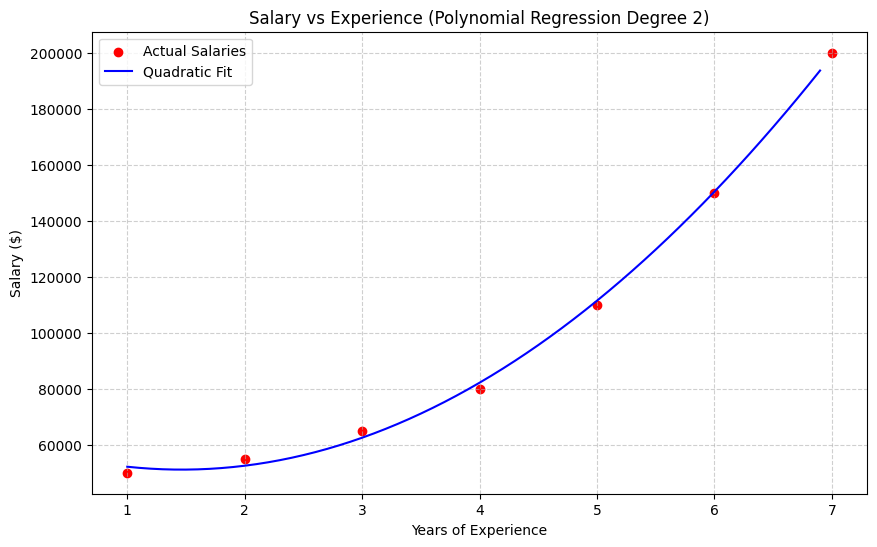

In [15]:
# Create a smooth line for the prediction curve (optional)
X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1)
X_grid_poly = poly_reg.transform(X_grid)

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='red', label='Actual Salaries')
plt.plot(X_grid, lin_reg_2.predict(X_grid_poly), color='blue', label='Quadratic Fit')
plt.title('Salary vs Experience (Polynomial Regression Degree 2)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [16]:
# conclusion:
# the above given solution shows that the degree 2 polynomial correctly identifies that salary increases become significantly larger with higher levels of experience.
# in quadratic equation, the X^2 term (4821.43) is what causes the "upward bend" in the salary curve as experience increases